In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler,LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [7]:
sonar_dataset = pd.read_csv("D:\sonar data.csv",header = None)

In [8]:
sonar_dataset

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [10]:
sonar_dataset.shape

(208, 61)

In [29]:
sonar_dataset.describe() # describe() gives the statistical measure of the data

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [30]:
sonar_dataset.isnull().sum()

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Length: 61, dtype: int64

In [31]:
sonar_dataset[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

In [32]:
sonar_dataset.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


In [33]:
# 60 IS THE LABEL AND WE NEED TO SEPEARTE DATA FROM LABEL SEPARETLY

x = sonar_dataset.drop(columns=60,axis=1)
y = sonar_dataset[60]

In [34]:
x

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0203,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0051,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0155,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0042,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048


In [35]:
y

0      R
1      R
2      R
3      R
4      R
      ..
203    M
204    M
205    M
206    M
207    M
Name: 60, Length: 208, dtype: object

In [42]:
# STANDARDIZE THE DATA , TO BRING THE DATA WITHIN A FIXED RANGE

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [43]:
print(x)
print(y)

[[-0.39955135 -0.04064823 -0.02692565 ...  0.06987027  0.17167808
  -0.65894689]
 [ 0.70353822  0.42163039  1.05561832 ... -0.47240644 -0.44455424
  -0.41985233]
 [-0.12922901  0.60106749  1.72340448 ...  1.30935987  0.25276128
   0.25758223]
 ...
 [ 1.00438083  0.16007801 -0.67384349 ...  0.90652575 -0.03913824
  -0.67887143]
 [ 0.04953255 -0.09539176  0.13480381 ... -0.00759783 -0.70402047
  -0.34015415]
 [-0.13794908 -0.06497869 -0.78861924 ... -0.6738235  -0.29860448
   0.99479044]]
0      R
1      R
2      R
3      R
4      R
      ..
203    M
204    M
205    M
206    M
207    M
Name: 60, Length: 208, dtype: object


In [44]:
# TRAIN AND TEST SPLIT

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,stratify=y,random_state=1)

In [45]:
print(x.shape,x_train.shape,x_test.shape)

(208, 60) (187, 60) (21, 60)


In [46]:
# Logistic Regression

model = LogisticRegression()

In [47]:
# TRAINING THE Logistic Regression model

model.fit(x_train,y_train)

LogisticRegression()

In [48]:
x_train_pred = model.predict(x_train)
training_data_accuracy = accuracy_score(x_train_pred,y_train)

In [49]:
print("Accuracy score of predicting a training data : ", training_data_accuracy)

Accuracy score of predicting a training data :  0.9197860962566845


In [59]:
x_test_pred = model.predict(x_test)
testing_data_accuracy = accuracy_score(y_test,x_test_pred)

In [60]:
print("Accuracy score of predicting a training data : ", testing_data_accuracy)

Accuracy score of predicting a training data :  0.7619047619047619


In [61]:
# Display Accuracy and Perfromance metrics

print(f'Logistic Regression Accuracy:{testing_data_accuracy*100:.2f}')

Logistic Regression Accuracy:76.19


In [62]:
print(f'Logistic Regression Accuracy:{testing_data_accuracy}')

Logistic Regression Accuracy:0.7619047619047619


In [64]:
print(classification_report(y_test,x_test_pred))

              precision    recall  f1-score   support

           M       0.75      0.82      0.78        11
           R       0.78      0.70      0.74        10

    accuracy                           0.76        21
   macro avg       0.76      0.76      0.76        21
weighted avg       0.76      0.76      0.76        21



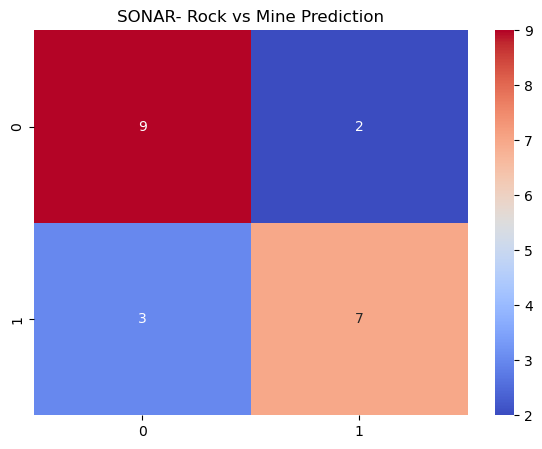

In [67]:
# CONFUSION MATRIX

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,x_test_pred),annot=True,cmap='coolwarm',fmt='d')
plt.title("SONAR- Rock vs Mine Prediction")
plt.show()

In [78]:
# MAKING A PREDICTIVE SYSTEM TO CHECK IF A PERSON HAS DIABETES OR NOT

input_data =(0.0180,0.0444,0.0476,0.0698,0.1615,0.0887,0.0596,0.1071,0.3175,0.2918,0.3273,0.3035,0.3033,0.2587,0.1682,0.1308,0.2803,0.4519,0.6641,0.7683,0.6960,0.4393,0.2432,0.2886,0.4974,0.8172,1.0000,0.9238,0.8519,0.7722,0.5772,0.5190,0.6824,0.6220,0.5054,0.3578,0.3809,0.3813,0.3359,0.2771,0.3648,0.3834,0.3453,0.2096,0.1031,0.0798,0.0701,0.0526,0.0241,0.0117,0.0122,0.0122,0.0114,0.0098,0.0027,0.0025,0.0026,0.0050,0.0073,0.0022)

# CONVERTING INPUT DATA INTO NUMPY ARRAYS AS IT IS MORE EFFICIENT

input_data_numpy_array = np.asarray(input_data)

# RESHAPING THE INPUT DATA FOR ONE INSTANCE

input_data_reshaped = input_data_numpy_array.reshape(1,-1)

# STANDARIZE THE INPUT DATA

std_data = scaler.transform(input_data_reshaped)
print(std_data)

# PREDICTING THE INPUT STANDARD DATA

prediction = model.predict(std_data)
print(prediction)

if (prediction[0] == 'M'):       #  prediction[0] is used bcz it only gives a single integer not an entire array or lists
    print("It is a Mine")
else:
    print("It is a Rock")    

[[0.018  0.0444 0.0476 0.0698 0.1615 0.0887 0.0596 0.1071 0.3175 0.2918
  0.3273 0.3035 0.3033 0.2587 0.1682 0.1308 0.2803 0.4519 0.6641 0.7683
  0.696  0.4393 0.2432 0.2886 0.4974 0.8172 1.     0.9238 0.8519 0.7722
  0.5772 0.519  0.6824 0.622  0.5054 0.3578 0.3809 0.3813 0.3359 0.2771
  0.3648 0.3834 0.3453 0.2096 0.1031 0.0798 0.0701 0.0526 0.0241 0.0117
  0.0122 0.0122 0.0114 0.0098 0.0027 0.0025 0.0026 0.005  0.0073 0.0022]]
['M']
It is a Mine
